## Import the Libraries and load the data

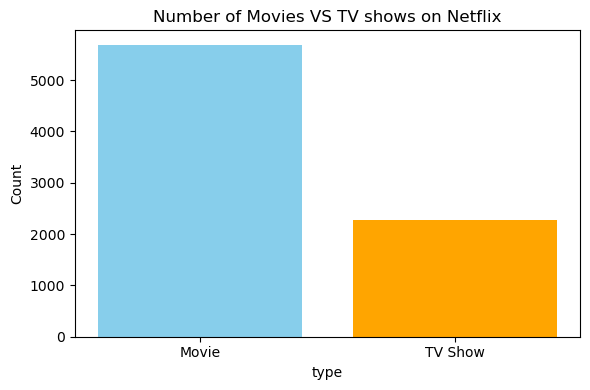

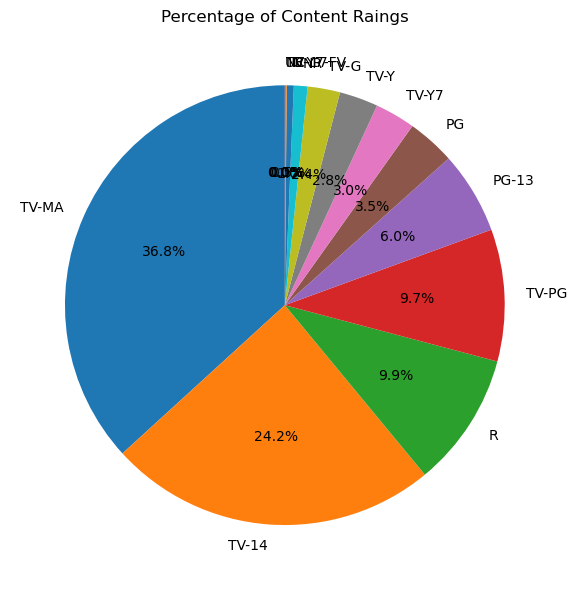

In [2]:
#import the libraries
import pandas as pd
import matplotlib.pyplot as plt

# load the data
df = pd.read_csv(r"C:\Users\93sha\Downloads\netflix_titles.csv")
df.head()

# clean
df = df.dropna(subset=["type", "release_year", "rating", "country", "duration"])

# Bar plot
type_counts = df["type"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts, color=["skyblue", "orange"])
plt.title("Number of Movies VS TV shows on Netflix")
plt.xlabel("type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("movies_vs_tvshows.png")
plt.show()

# Pie Chart
rating_counts = df["rating"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(rating_counts, labels=rating_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Percentage of Content Raings")
plt.tight_layout()
plt.savefig("Content_Rating.png")
plt.show()

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [4]:
# Handling missing values
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\93sha\Downloads\netflix_titles.csv")
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# Extracting unique values for every column from the data
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [6]:
# data shape means (rows * columns)
df.shape

(8807, 12)

In [7]:
## Dropping the null values
df.dropna(inplace = True)

## It actually shows True if True and False, if your dataset has a null value it shows True and otherwise False, which means your dataset has no null values. Dataset is ready for visualization or can gain insights from the data effectively.

In [9]:
## Check null values
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False,False,False,False
24,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,False,False,False,False,False,False,False,False,False,False,False,False
8802,False,False,False,False,False,False,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [11]:
# data duplicates values
df.duplicated().sum()

0

In [12]:
## Describe the dataset
df.describe()

,release_year
count,5332.000000
mean,2012.742123
std,9.625831
min,1942.000000
25%,2011.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.index

Index([   7,    8,    9,   12,   24,   27,   28,   29,   38,   41,
       ...
       8792, 8793, 8794, 8798, 8799, 8801, 8802, 8804, 8805, 8806],
      dtype='int64', length=5332)

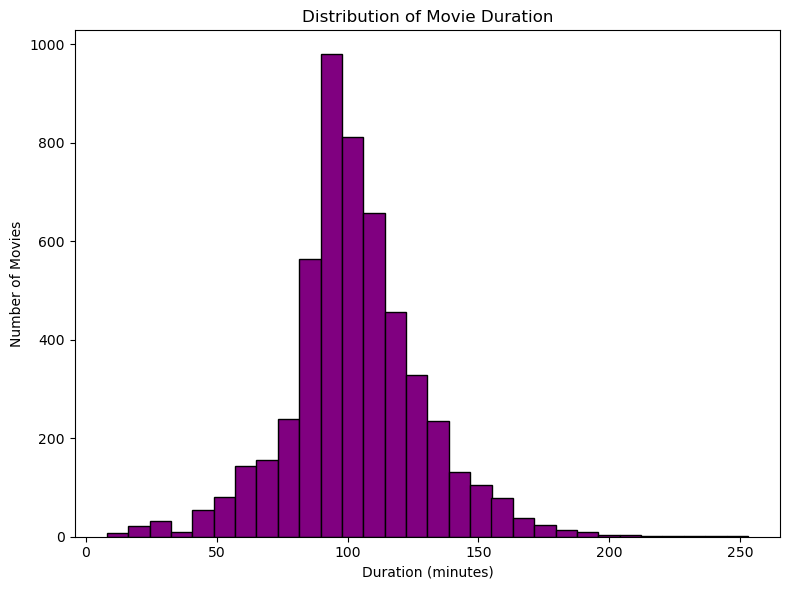

In [15]:
## Histogram
import matplotlib.pyplot as plt
import pandas as pd

# Filter only movies
movie_df = df[df["type"] == "Movie"].copy()

# Remove 'min' and convert safely to integer
movie_df["duration_int"] = (movie_df["duration"].str.replace("min", "", regex=False)  # remove 'min'
    .str.strip()                          # remove spaces
    .replace("", pd.NA)                   # replace empty strings with NA
    .astype(float)                        # convert safely to float
)

# Drop rows where conversion failed
movie_df = movie_df.dropna(subset=["duration_int"])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(movie_df["duration_int"], bins=30, color="purple", edgecolor="black")
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("movie_duration_histogram.png")
plt.show()


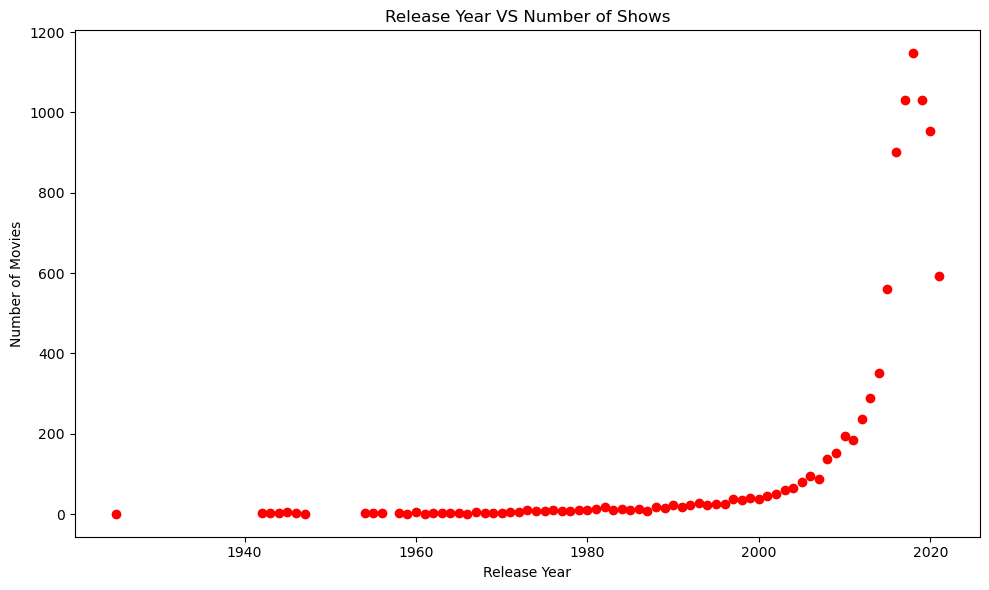

In [16]:
# Scatter Plot
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv(r"C:\Users\93sha\Downloads\netflix_titles.csv")
release_counts = df["release_year"].value_counts().sort_index()
plt.figure(figsize=[10, 6])
plt.scatter(release_counts.index, release_counts.values, color="red")
plt.title("Release Year VS Number of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("release_year_scatter.png")
plt.show()


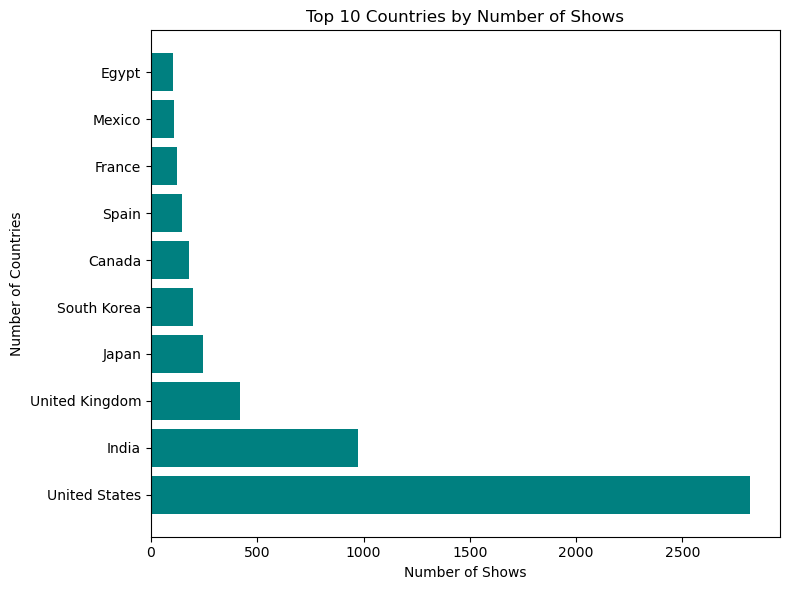

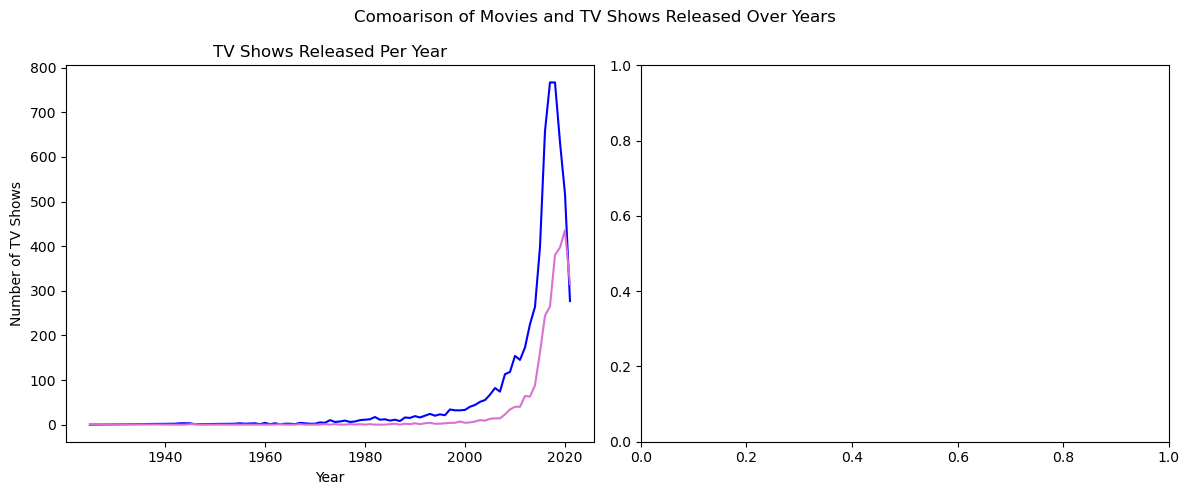

In [17]:
## Top 10 countries by number of Shows
country_counts = df["country"].value_counts().head(10)
plt.figure(figsize=(8, 6))
plt.barh(country_counts.index, country_counts.values, color="teal")
plt.title("Top 10 Countries by Number of Shows")
plt.xlabel("Number of Shows")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.savefig("top10_countries.png")
plt.show()

content_by_year = df.groupby(["release_year", "type"]).size().unstack().fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

## First Subplot
## Comparison of Movies and TV Shows Over the Years
ax[0].plot(content_by_year.index, content_by_year["Movie"], color="blue")
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")

ax[0].plot(content_by_year.index, content_by_year["TV Show"], color="orchid")
ax[0].set_title("TV Shows Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of TV Shows")

fig.suptitle("Comoarison of Movies and TV Shows Released Over Years")
plt.tight_layout()
plt.savefig("movie_tv_shows_comparison.png")

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'date_added' to datetime (handle invalid/missing gracefully)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract date components
df["day_added"] = df["date_added"].dt.day
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Fill missing values with 0 (or drop them if you prefer)
df["day_added"] = df["day_added"].fillna(0).astype(int)
df["year_added"] = df["year_added"].fillna(0).astype(int)
df["month_added"] = df["month_added"].fillna(0).astype(int)

# Optional: check a few rows
df[["date_added", "day_added", "month_added", "year_added"]].head(50)



,date_added,day_added,month_added,year_added
0,2021-09-25,25,9,2021
1,2021-09-24,24,9,2021
2,2021-09-24,24,9,2021
3,2021-09-24,24,9,2021
4,2021-09-24,24,9,2021
5,2021-09-24,24,9,2021
6,2021-09-24,24,9,2021
7,2021-09-24,24,9,2021
8,2021-09-24,24,9,2021
9,2021-09-24,24,9,2021


errors="coerce"	Converts invalid dates to NaT instead of crashing.	Keeps your code safe even if the column has dirty data.

.dt.day, .dt.month, .dt.year	Extracts day, month, year.	Lets you analyze trends over time.

.fillna(0)	Replaces NaN with 0 before converting to int.	Prevents ValueError: cannot convert float NaN to integer.

.astype(int)	Converts the float columns (with missing values filled) to integers.	Makes them easier to work with for analysis and visualization.

C:\Users\93sha\AppData\Local\Temp\ipykernel_15512\3779223646.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(df['rating']).set_xticklabels(sns.countplot(df['rating']).get_xticklabels(), rotation=90, ha="right")


Text(0.5, 1.0, 'Rating')

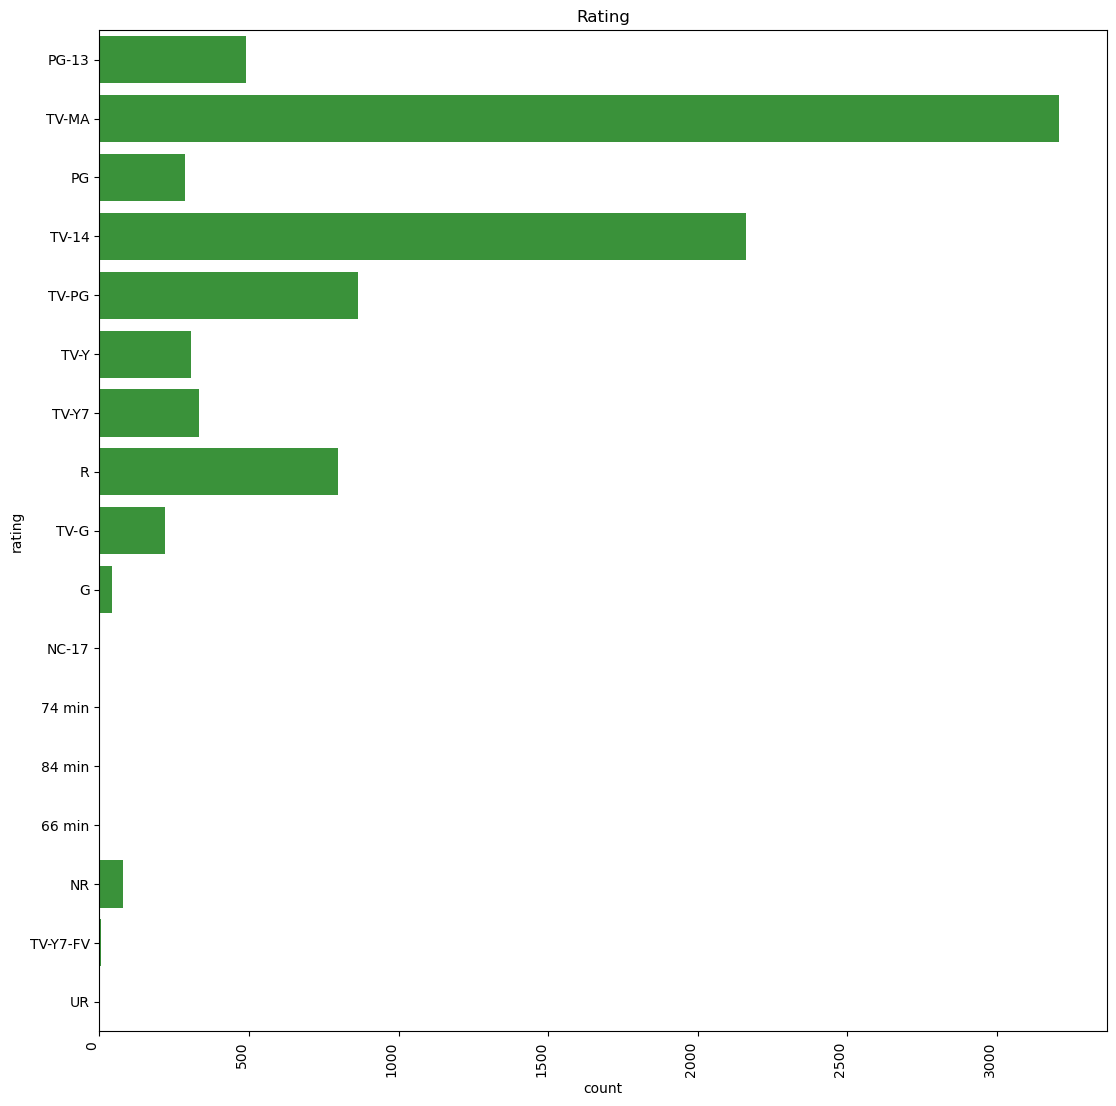

In [20]:
## Rating of shows and movies
import seaborn as sns
import pandas as pd
df = pd.read_csv(r"C:\Users\93sha\Downloads\netflix_titles.csv")
sns.countplot(df['rating'])
sns.countplot(df['rating']).set_xticklabels(sns.countplot(df['rating']).get_xticklabels(), rotation=90, ha="right")
fig = plt.gcf()
fig.set_size_inches(13,13)
plt.title('Rating')

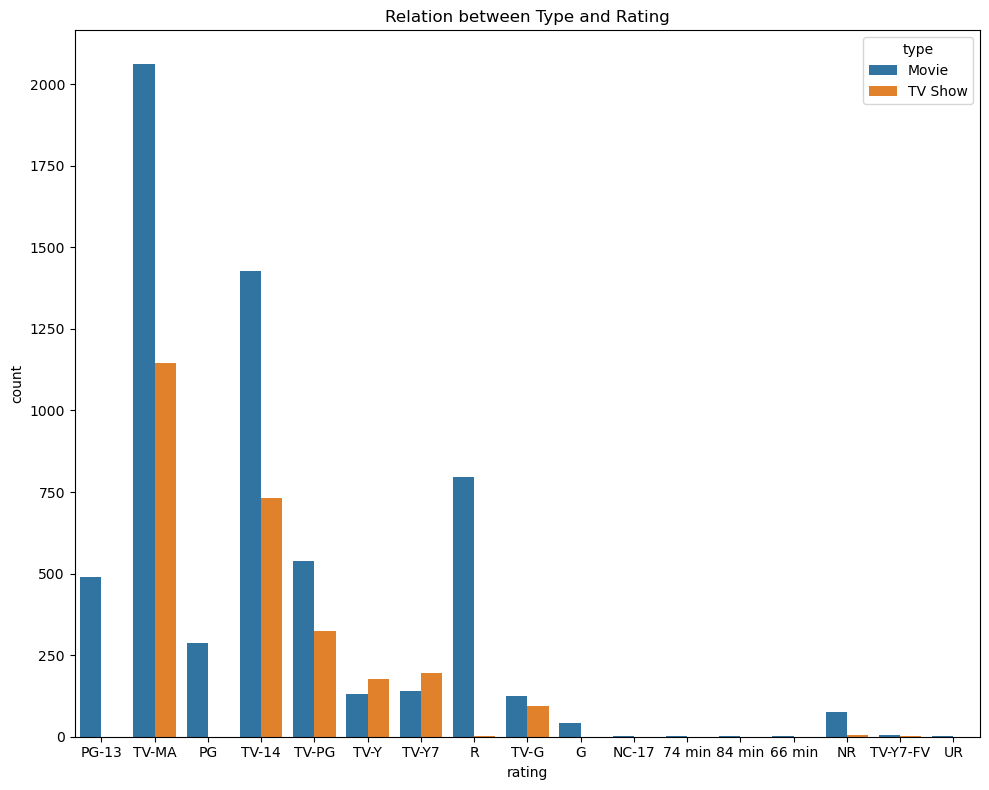

In [21]:
## Relation between Type and Rating
plt.figure(figsize=(10,8))
sns.countplot(x='rating',hue='type',data=df)
plt.title('Relation between Type and Rating')
plt.tight_layout()
plt.show()

In [22]:
# Visual insights with numerical data
df.groupby(['rating', 'type']).size().unstack(fill_value=0)

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


In [23]:
from wordcloud import WordCloud

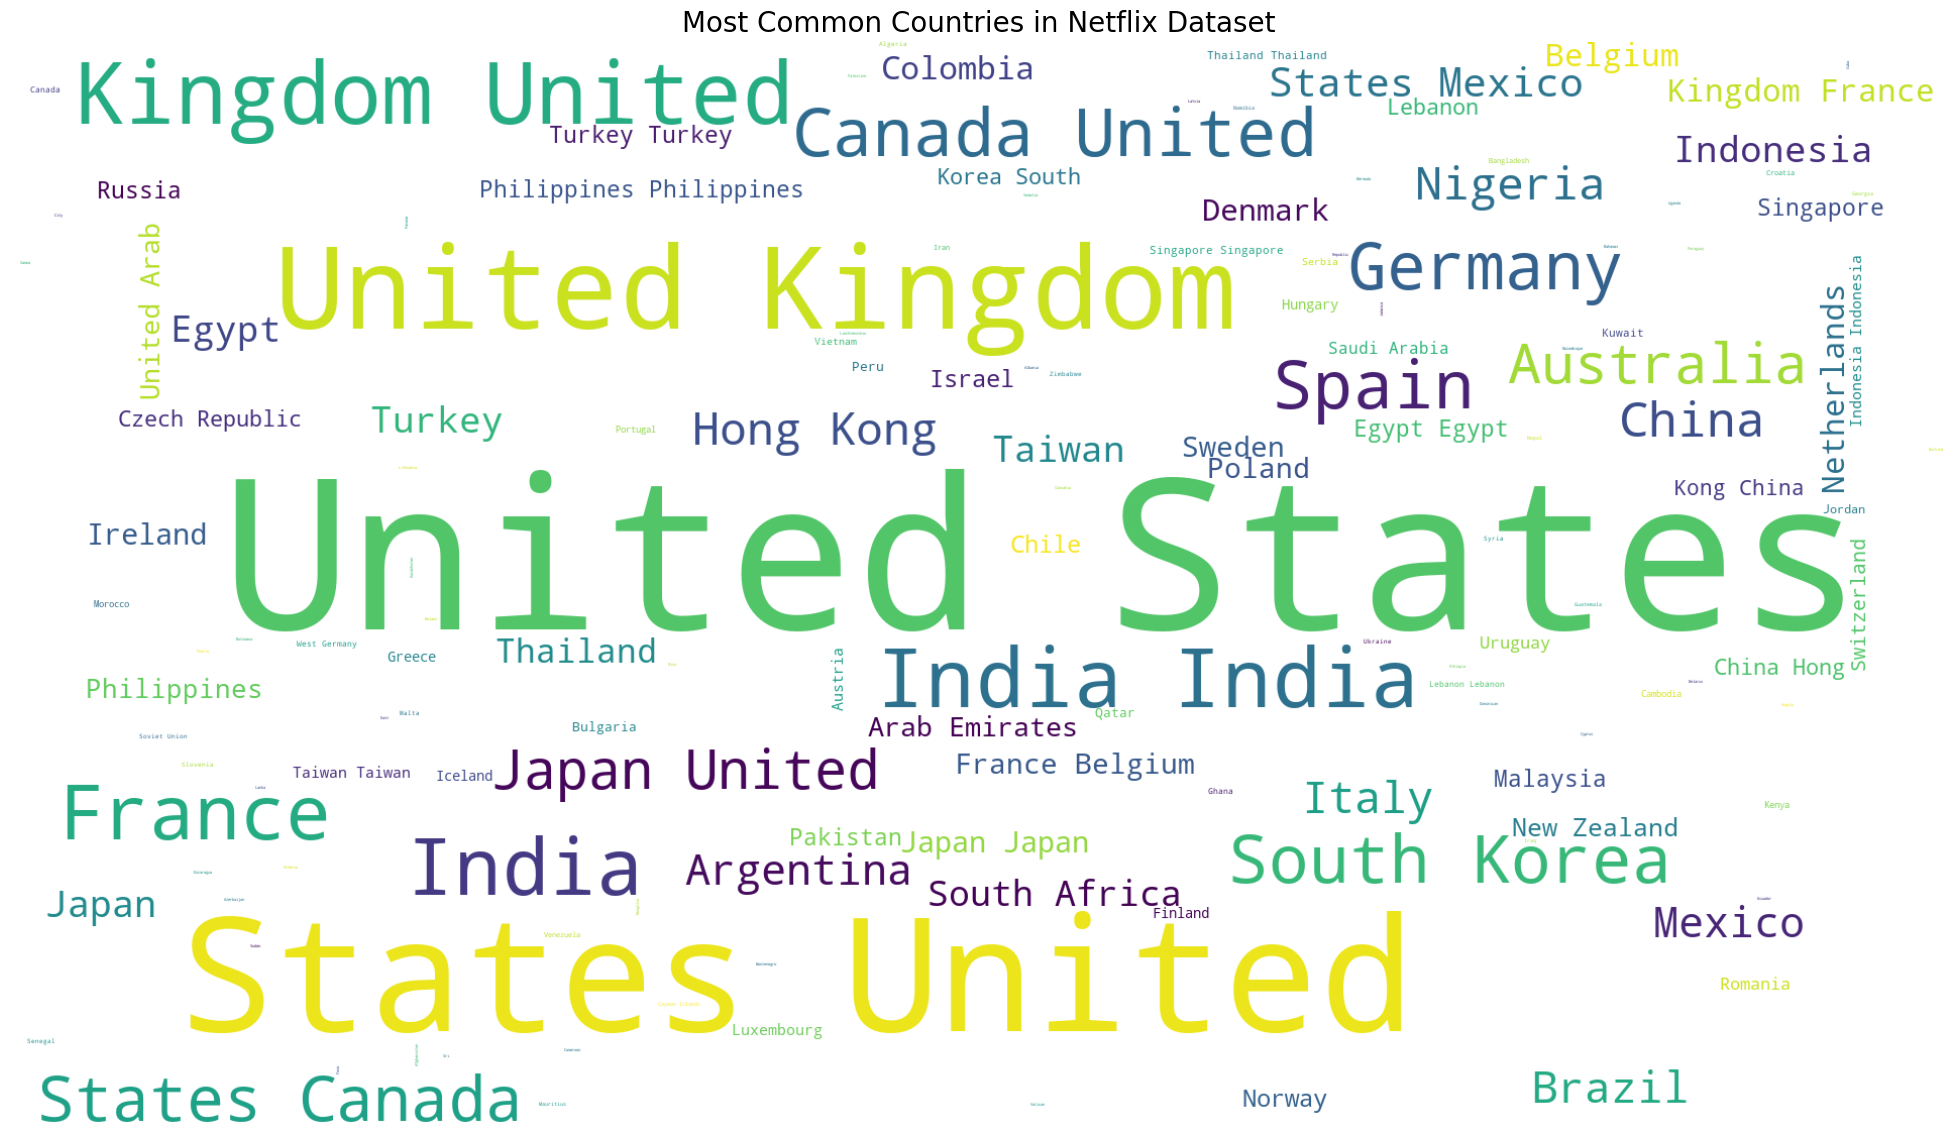

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

countries = df['country'].dropna()

# Generate the word cloud text
text = " ".join(countries)

# Create the word cloud
plt.figure(figsize=(25, 15))
wordcloud = WordCloud(
    background_color='white',
    width=1920,
    height=1080
).generate(text)

# Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Countries in Netflix Dataset', fontsize=20)
plt.savefig('country.png')
plt.show()


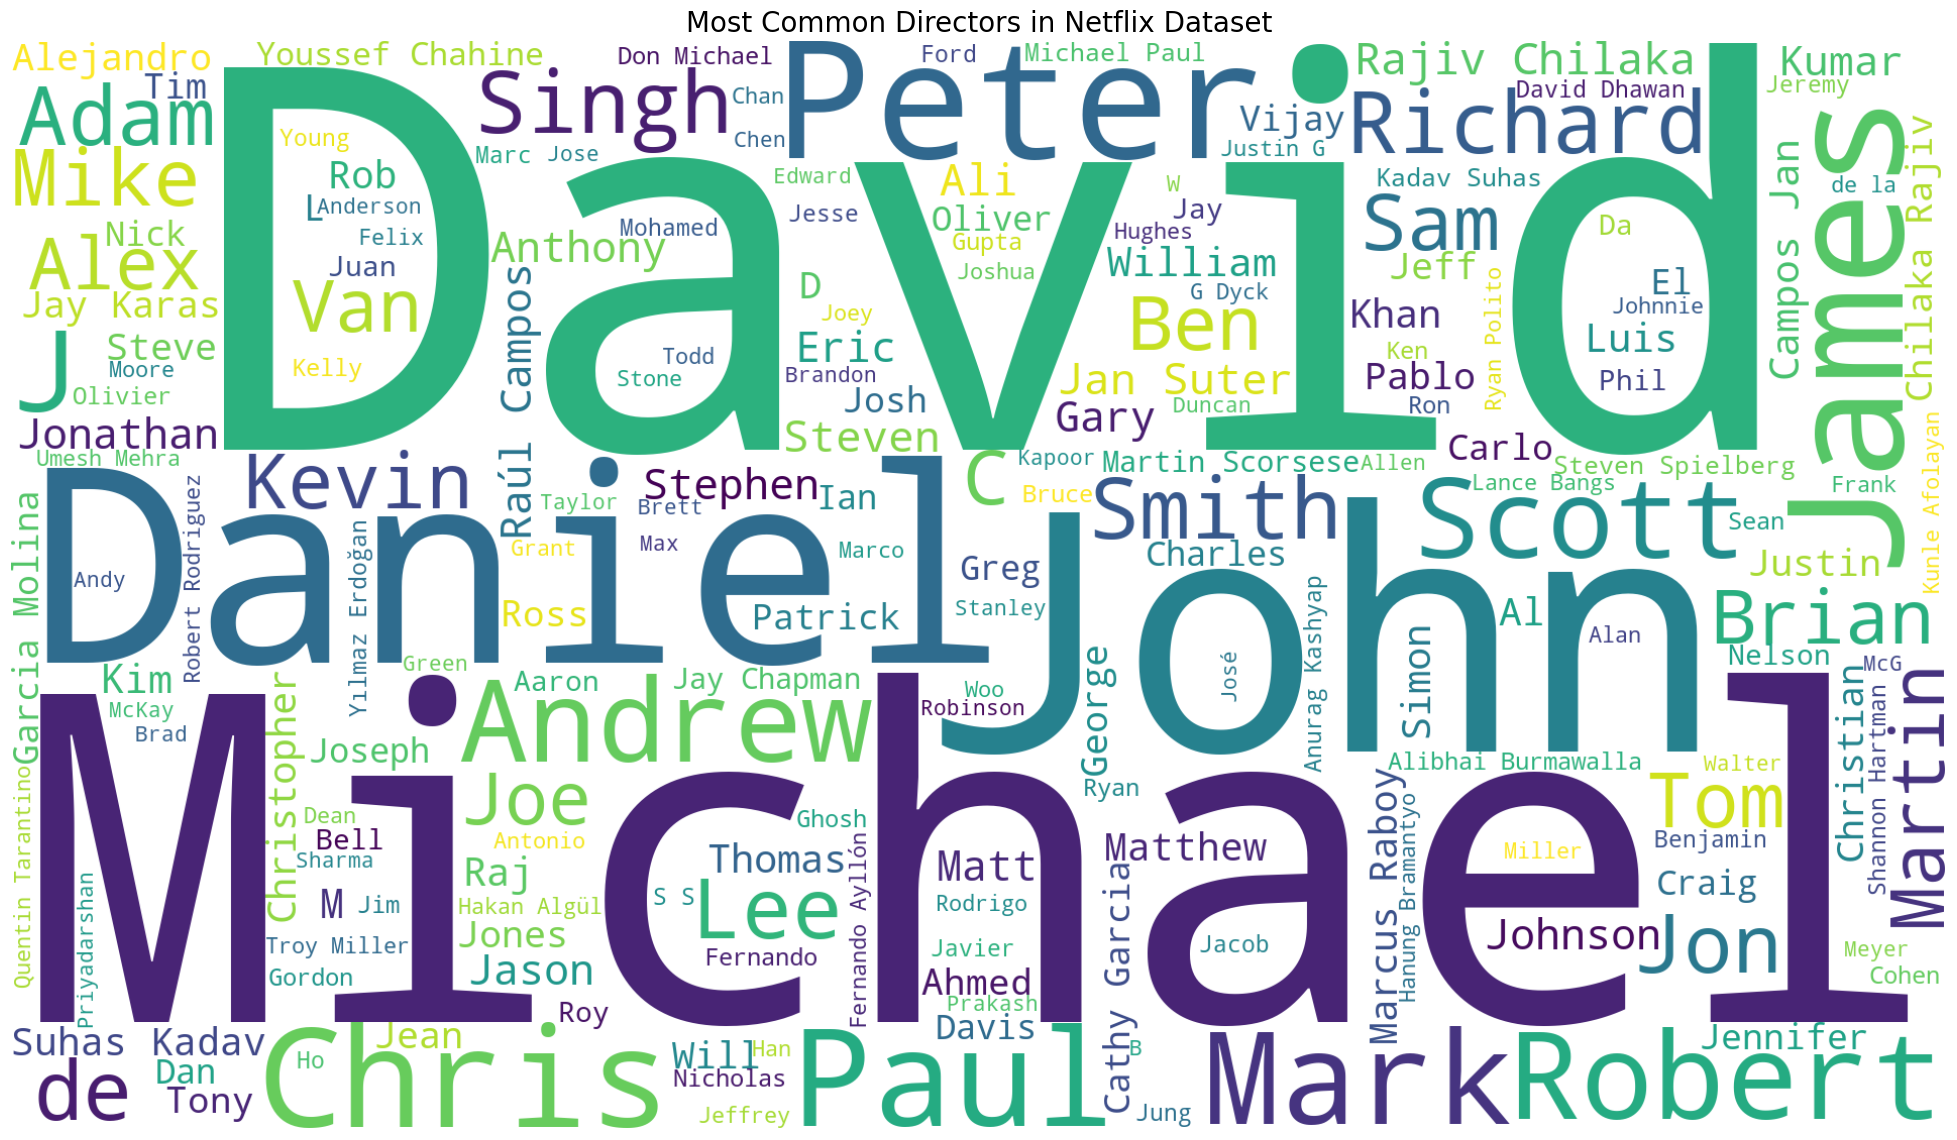

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Drop missing values
directors = df['director'].dropna()

# Join all director names into one long string
text = " ".join(directors)

plt.figure(figsize=(25, 15))
wordcloud = WordCloud(
    background_color='white',
    width=1920,
    height=1080
).generate(text)

# Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Directors in Netflix Dataset', fontsize=20)
plt.savefig('director.png')
plt.show()


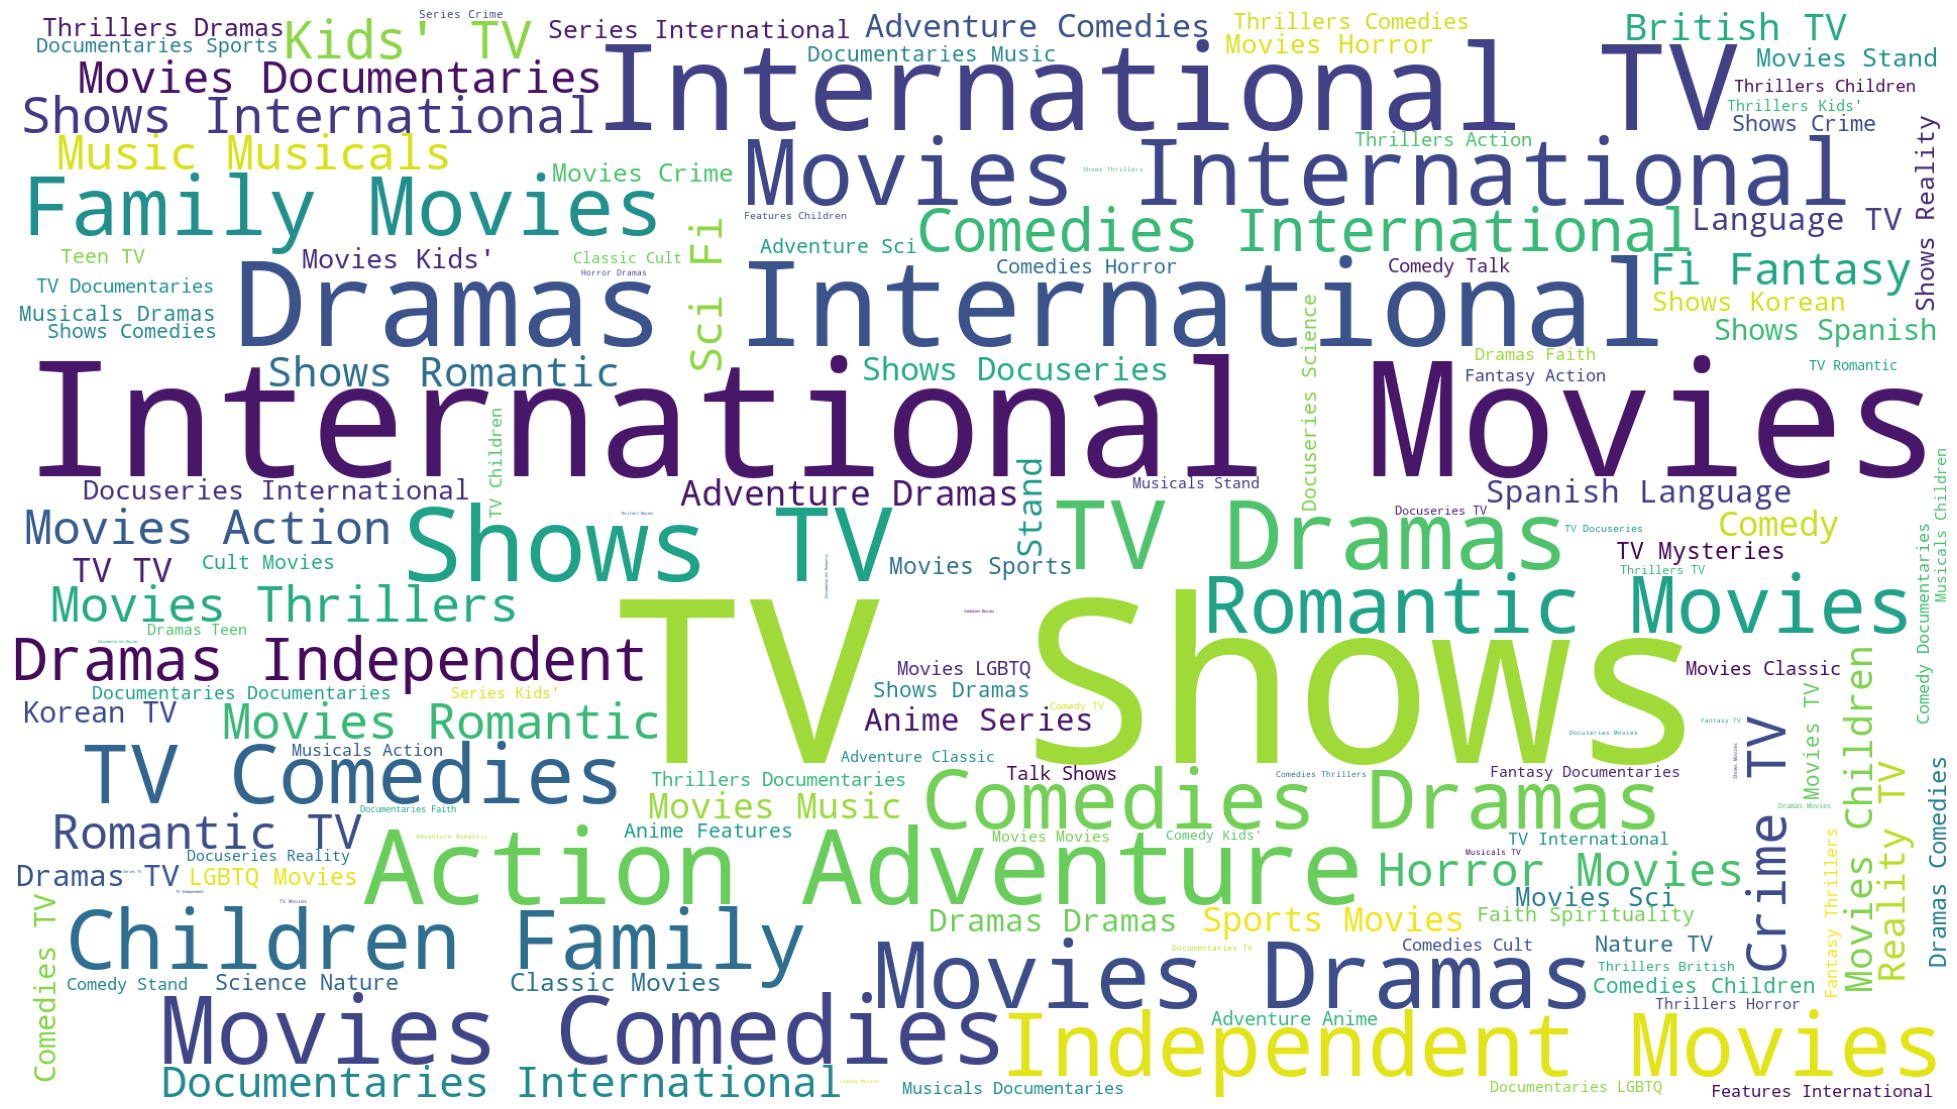

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## Handling missing values
lists = df["listed_in"].dropna()

## join all listed in a long string 
text = "".join(lists)

## Now make a subplot or display the word cloud
plt.figure(figsize=(25,15))
wordcloud = WordCloud(background_color='white', width=1920, height=1080).generate(" ".join(df.listed_in))
plt.imshow(wordcloud)
plt.axis('off')
plt.savefig('category.png')
plt.show()